In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 11,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Set up simulation

In [2]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Load data

In [3]:
Q_nom = 4.6
t_end = 13*60 #100B is only 13 mins of ESC

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
    data['Cell Temperature'][data['Cell Temperature']>140] = None
    data.interpolate(inplace=True)
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = (data['Force'] - data['Force'].loc[esc_start])*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    if SOC_name =='100B':
        data['V'][(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B

    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

In [4]:
datas = []
SOC_names = ['100A','100B','75', '50']#['100A','100B', '75', '50'] 
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

for SOC_name in SOC_names: 
    # load data and sim 
    SOC_0 = SOC_0s[SOC_name]
    data = load_data(SOC_0, SOC_name)[0]    
    datas.append(data)

C:\Users\Vivian\AppData\Local\Temp\ipykernel_2512\977535796.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_2512\977535796.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_2512\977535796.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_2512\977535796.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `ob

In [5]:
def ocv(soc):
    p0 = np.array([0.114319142120841,  -0.663997904709863, 
            1.686768366470837,  -2.462409468590447,   2.282769243949050, 
            -1.401600551327618,   0.576551904459066,  -0.157044814050174, 
            0.027351974716897,  -0.002866912229499,   0.000171009483610,
            0.000029999998915])*1e5
    return np.polyval(p0,soc)

# Nondimensional

## Check that model runs

In [6]:
def sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I, dV):  
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        # "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)

    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature")

    # Init model and variables
    liion = pybamm.LithiumIonParameters()
    model = pybamm.BaseModel()
    Delta_T = param.evaluate(liion.Delta_T)
    T_ref = param.evaluate(liion.T_ref)
    tau_discharge = param.evaluate(liion.tau_discharge)
    tau_th_yz = param.evaluate(liion.tau_th_yz)
    model.timescale = pybamm.Scalar(tau_discharge)
    model.variables = {
        "Volume-averaged total heating": Q_vol_av, 
        "Volume-averaged cell temperature": T_vol_av,
        "Volume-averaged cell temperature [K]": Delta_T * T_vol_av + T_ref,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    # thermal = pybamm.thermal_parameters
    delta = param.evaluate(liion.delta) #self.L_x / self.L_z
    cell_surface_area = param.evaluate(liion.a_cooling) #self.A_cooling / (self.L_z ** 2)
    cell_volume = param.evaluate(liion.v_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
    h_total = param.evaluate(liion.h_total) # self.h_total_dim * self.geo.L_x / self.lambda_eff_dim_ref
    rho = param.evaluate(liion.rho(T_vol_av)) # Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
    T_amb = param.evaluate(liion.T_amb(0)) # (self.T_amb_dim(t) - self.T_ref) / self.Delta_T
    total_cooling_coefficient = (
        -h_total
        * cell_surface_area
        / cell_volume
        / (delta ** 2))
    B = param.evaluate(liion.B) #self.B = (self.i_typ* self.R* self.T_ref* self.tau_th_yz/ (self.therm.rho_eff_dim_ref * self.F * self.Delta_T * self.L_x))
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)


    model.variables.update({
    "Volume-averaged total heating [W.m-3]": Q_vol_av * Q_scale,
    })

    # RHS
    model.rhs = {
        T_vol_av: (
            B * Q_vol_av + total_cooling_coefficient * (T_vol_av - T_amb)
        )/ (C_th * rho)
    }
    
    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_nom = param["Cell capacity [A.h]"]
    AhT_calculated = integrate.cumtrapz(abs(I), t-t[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    soc = SOC_0 - AhT_calculated/Q_nom 
    Q_data = I*dV #(ocv(soc)-V)

    # solve
    sim = pybamm.Simulation(model)
    V_cell_norm = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 

    for (dt,q) in zip(np.diff(t), Q_data[0:-1]):
        external_variables = {"Volume-averaged total heating": q/V_cell_norm/Q_scale} 
        sim.step(dt, external_variables=external_variables)
    return sim


## Set up loss function

In [7]:
T_bp = 107 #degC
if SOC_0 !=0.5: # doesn't get hot enough
    t_boiling = data.t[(T_bp-data.Temp)<0.2].iloc[0] 

data = datas[0]

def loss_T_nondim(k:np.ndarray): 
    
    h = k[0]
    Cp = k[1]
    T_amb_0 = data.Temp[0]
    I = data.I
    dV = ocv(data.SOC)-data.V
    t = data.t
    solution = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I, dV).solution

    # if SOC_0 ==1:
        # t_vap = [t_boiling, 90] #100%SOC
        # time_window = (data.t<t_vap[0]) | (data.t>t_vap[1])
        # time_window = data.Temp<110
    # w = (data.Temp.iloc[0:-1]<T_bp).astype(int) + 0.1*(data.Temp.iloc[0:-1]>T_bp).astype(int) # decrease weight while vaporizing
    w = (data.Temp<T_bp).astype(int) + 0.1*(data.Temp>T_bp).astype(int) # decrease weight while vaporizing
    t = data.t#.iloc[0:-1]
        # time_window_vap = data.Temp>110
    dTdt_data = np.diff(data.Temp.iloc[0:-1])/np.diff(data.t.iloc[0:-1])
    # elif SOC_0 ==0.75:
    #     t_vap = [50, 110]#75%SOC
    #     # time_window = (data.t<t_vap[0]) | (data.t>t_vap[1])
    #     time_window = data.Temp<110
    #     t = data.t[time_window].iloc[0:-1]
    #     dTdt_data = np.diff(data.Temp[time_window].iloc[0:-1])/np.diff(data.t[time_window].iloc[0:-1])
    # else: 
    #     dTdt_data = np.diff(data.Temp.iloc[0:-1])/np.diff(data.t.iloc[0:-1])
    #     t_vap = []
    # t = data.t[0:-1]
    # dTdt_data = np.diff(data.Temp[0:-1])/np.diff(data.t[0:-1])

    # calculate squared sum for rest period
    T = solution['Volume-averaged cell temperature [K]']
    loss_T = np.mean(np.square(data.Temp[0:-1]- (T(data.t[0:-1])-273.15)).iloc[0:-1])#/np.mean(data.Temp[0:-1]) #12/31
    # loss_T = np.mean(np.square(data.Temp[0:-1]- (T(data.t[0:-1])-273.15))*w.iloc[0:-1])#/np.mean(data.Temp[0:-1]) #12/30
    # loss_T = np.linalg.norm(data.Temp[0:-1]- (T(data.t[0:-1])-273.15), ord = 1)
    # liion = pybamm.LithiumIonParameters()
    # tau_discharge = param.evaluate(liion.tau_discharge)
    # loss_T = np.linalg.norm(np.diff(data.Temp[0:-1]) - np.diff(T(data.t[0:-1]))) # avoid nan
    
    dTdt_sim = np.diff(T(t))/np.diff(t)
    # filtered_dTdt_data = signal.savgol_filter(dTdt_data, 10*5,3)
    filtered_dTdt_data = signal.savgol_filter(data.Temp, 10*15,3, deriv=1)/signal.savgol_filter(data.t, 10*15,3, deriv=1)
    # dTdt_sim =  signal.savgol_filter(T(t), 10*5,3, deriv=1)/signal.savgol_filter(t, 10*5,3, deriv=1)
    loss_dT = np.mean(np.square(filtered_dTdt_data[1:-1] - dTdt_sim[0:-1]))*1000*0 #/np.mean(abs(filtered_dTdt_data[1:-1] - dTdt_sim[0:-1])) #12/30
    # loss_dT = np.mean(abs(filtered_dTdt_data - dTdt_sim))
    # loss_dT = np.sqrt(np.mean(np.square(filtered_dTdt_data - dTdt_sim)))
    # loss_dT = np.linalg.norm((filtered_dTdt_data[0:-1] - dTdt_sim[0:-1]), ord = 1)*100 + np.linalg.norm((data.Temp.iloc[0:-1] - T(t.iloc[0:-1])), ord = 1)
    # loss_dT = np.linalg.norm((filtered_dTdt_data - dTdt_sim)*w.iloc[0:-1], ord = 1) #*w.iloc[0:-1]
    # loss_dT = np.linalg.norm((filtered_dTdt_data - dTdt_sim)*w.iloc[0:-1], ord = 2) #*w.iloc[0:-1]
    # loss_dT = np.mean(np.square((filtered_dTdt_data - dTdt_sim)*w))/np.mean(filtered_dTdt_data)#*w.iloc[0:-1]
    # loss_dT = np.linalg.norm((filtered_dTdt_data[1:-1] - dTdt_sim[0:-1]), ord = 2)*0
    # loss_T = np.linalg.norm((data.Temp.iloc[0:-1] - T(t.iloc[0:-1])), ord = 2)

    print([k, loss_dT, loss_T, loss_dT + loss_T])
    return np.array([loss_T])#<---------------changed
    # print([loss_T])
    # return np.array([loss_T])#<---------------changed

# test function
# print(loss_T_nondim(np.array([35,  1.2])))
# print(loss_T_nondim(np.array([20,  1.2])))

In [8]:
# SOC_0 = SOC_0s[SOC_names[0]]
# T_amb_0 = data.Temp[0]
# I = data.I
# dV = ocv(data.SOC)-data.V
# t = data.t
# h=33
# Cp=2.2

# solution = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I, dV).solution
# T = solution['Volume-averaged cell temperature [K]']
# dTdt_sim = np.diff(T(t))/np.diff(t)
# filtered_dTdt_data = signal.savgol_filter(data.Temp, 10*15,3, deriv=1)/signal.savgol_filter(data.t, 10*15,3, deriv=1)
# filtered_dTdt_data - dTdt_sim
# np.mean(np.square(filtered_dTdt_data[1:-1] - dTdt_sim[0:-1]))/np.mean(abs(filtered_dTdt_data[1:-1] - dTdt_sim[0:-1]))


## Fit thermal parameters

In [12]:
# took ~12.3 hrs to run
k_hs= []
k_Cps= []
# 100A [33.49523017  2.52552319] rmseT [33.3878717  2.5478592] weighted T
for (SOC_name,data) in zip(SOC_names, datas):
    print(SOC_name)

    SOC_0 = SOC_0s[SOC_name]
    T_amb_0 = data.Temp[0]
    I = data.I
    dV = ocv(data.SOC)-data.V
    t = data.t

    # Fit thermal params
    k0 = np.array([20,2]) #[h, k_cp] cp = cp0*k_cp 
    lb = np.array([5,0.1])
    ub = np.array([50,10])
    k = dfols.solve(loss_T_nondim, k0, bounds = (lb,ub), rhoend=1e-2)


    # update fitted thermal params
    h = k.x[0]
    Cp = k.x[1]
    solution = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I, dV).solution
    t_sol, y_sol = solution.t, solution.y  # get solution times and states
    k_hs.append(k.x[0])
    k_Cps.append(k.x[1])
    print(k.x)
  

100A


2023-12-30 23:16:49.676 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[array([20.,  2.]), 0.0, 1060.2945622043328, 1060.2945622043328]


2023-12-30 23:16:59.676 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[array([22.,  2.]), 0.0, 779.6358140603392, 779.6358140603392]


...

[array([35.31863975,  1.80691199]), 0.0, 12.899031215673865, 12.899031215673865]


2023-12-31 12:39:33.931 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[array([35.32130769,  1.78709074]), 0.0, 13.014313930591706, 13.014313930591706]


2023-12-31 12:39:54.000 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


[array([35.30863977,  1.806931  ]), 0.0, 12.938583751188727, 12.938583751188727]
[35.31863975  1.80691199]


## Plot data vs model

In [14]:
print(k_hs)
print(k_Cps)

[34.83874617168782, 34.211742173359575, 37.17732764082647, 35.31863975361435]
[2.4847642158614396, 2.131841251256563, 1.7615851440073333, 1.8069119898506183]


100A


2024-01-02 10:54:07.273 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-02 10:54:07.306 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


100B


2024-01-02 10:55:25.980 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-02 10:55:25.999 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


75


2024-01-02 10:56:49.466 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-02 10:56:49.487 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


50


2024-01-02 10:58:03.710 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-02 10:58:03.728 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


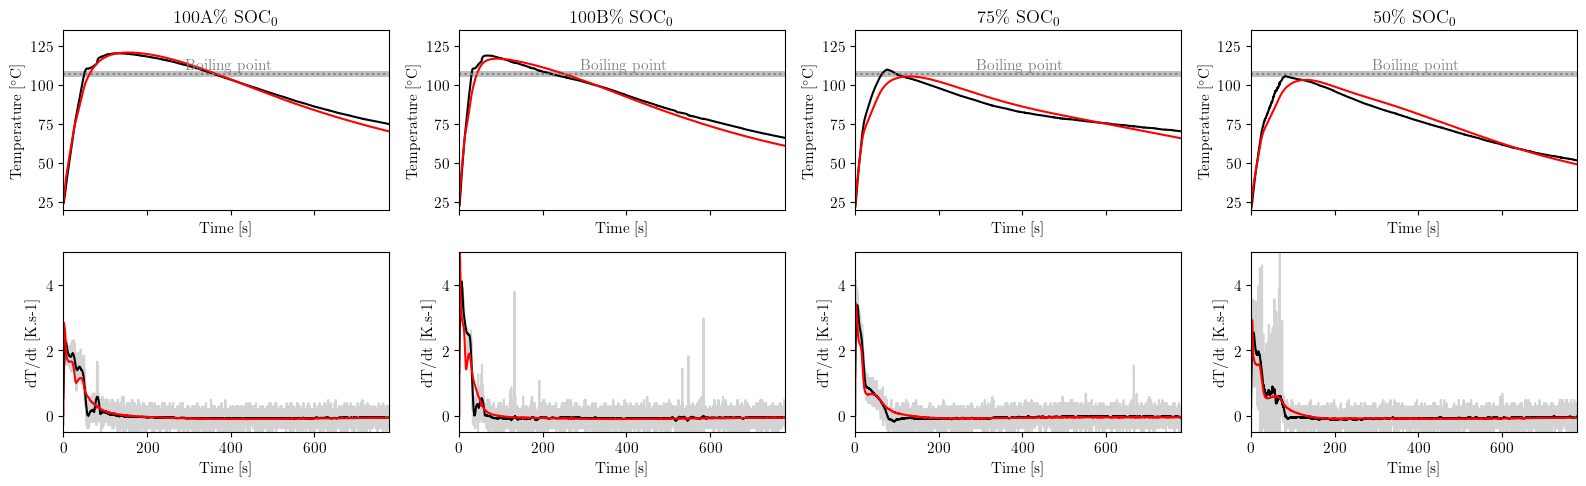

,SOC_names,k_hs,k_Cps,RMSE_dTs,RMSE_Ts
0,100A,34.838746,2.484764,0.142327,2.426947
1,100B,34.211742,2.131841,0.229355,3.310610
2,75,37.177328,1.761585,0.134493,4.037168
3,50,35.318640,1.806912,0.140224,3.591407


In [7]:
%matplotlib inline
# plot 
RMSE_dTs = []
RMSE_Ts = []
k_hs =[34.83874617168782, 34.211742173359575, 37.17732764082647, 35.31863975361435]
k_Cps = [2.4847642158614396, 2.131841251256563, 1.7615851440073333, 1.8069119898506183]
fig, axs= plt.subplots(2, len(SOC_names), figsize=(4*len(SOC_names), 5), sharex=True) #, constrained_layout=True
# ax = ax.flatten()
for i, (SOC_name,data, h, Cp) in enumerate(zip(SOC_names, datas, k_hs, k_Cps)):
    print(SOC_name)

    # set up data
    SOC_0 = SOC_0s[SOC_name]
    T_amb_0 = data.Temp[0]
    I = data.I
    dV = ocv(data.SOC)-data.V
    t = data.t

    # run sim with fitted values
    solution = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I, dV).solution
    t_sol, y_sol = solution.t, solution.y  # get solution times and states
    T_bp = 107
    T = solution["Volume-averaged cell temperature [K]"]
    RMSE_T = np.sqrt(np.mean(np.square(data.Temp- (T(data.t)-273.15))))

    dTdt_data = np.diff(data.Temp)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*16,3)
    T = solution['Volume-averaged cell temperature [K]']
    dTdt_sim = np.diff(T(data.t[0:-1]))/np.diff(data.t[0:-1])
    RMSE_dT = np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim)))

    # plot 
    ax = axs[0,i]
    ax.plot(data.t, data.Temp, color = 'k', label = "Data")
    ax.plot(data.t, T(data.t)-273.15, color = 'r', label = "Model (RMSE = " + str(np.round(RMSE_T, 1)) + '$^\circ$C)')
    ax.plot([0,t_end], [T_bp]*2, color = 'gray', linestyle = ':')
    ax.axhspan(T_bp-2.2, T_bp+2.2, facecolor ='gray', alpha = 0.5) 
    ax.annotate('Boiling point', xy=(t_end/2-100, T_bp+3), color = 'gray')
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Temperature [$^\circ$C]")
    # ax.legend()
    ax.set_title(SOC_name + "\% SOC$_0$")
    ax.set_xlim([0,t_end])
    ax.set_ylim([20,135])

    ax = axs[1,i]
    ax.plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Data: Calculated")
    ax.plot(data.t[0:-1], dT_filtered, color = 'k', label = "Data: S-G filtered")
    ax.plot(data.t[0:-2], dTdt_sim, color = 'r', label = "Model (RMSE = " + str(round(RMSE_dT, 2)) + " K.s-1)")
    ax.set_ylabel("dT/dt [K.s-1]")
    ax.set_xlabel("Time [s]")
    ax.set_ylim([-0.5, 5])
    ax.set_xlim([0,t_end])
    # ax[i,1].legend()

    t_boiling = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[0]
    if SOC_0 ==1:
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        t_vaps = [t_boiling, t_vent]
    else: 
        t_boiling2 = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[-1]
        t_vaps = [t_boiling, t_boiling2]

    # for axs in fig.get_axes():
    #     for i, t_vap in enumerate(t_vaps):
    #         ylims = axs.get_ylim()
    #         if i ==0:
    #             axs.plot([t_vap]*2, list(ylims), color = 'm', linestyle = '--', label = 'Electrolyte vaporization') #(T$>$' + str(T_bp) + '$^\circ$C)
    #         else:
    #             axs.plot([t_vap]*2, list(ylims), color = 'm', linestyle = '--')
    #         axs.set_ylim(ylims) # keep original limits
    #         axs.legend()
    #     if (SOC_0 ==1):# and (l == len(solutions)-1):
    #         # t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
    #         # T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
    #         # ylims = axs.get_ylim()
    #         # axs.annotate('Boiling', xy=(t_boiling-35, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
    #         # axs.plot([t_vent]*2, list(ylims), color = 'm', linestyle = '--')
    #         axs.annotate('Venting', xy=(t_vent, np.diff(ylims)*0.4+ ylims[0]), rotation=-90, color = 'm')
    #         axs.set_ylim(ylims) # keep original limits
                
    # fig.suptitle(str(int(1*100)) + "\% SOC$_0$", y=1, x = 0.55)
    # plt.savefig('./figs/' + SOC_name + 'ESC_thermal_fit.eps', format='eps', dpi = 300)
    RMSE_dTs.append(RMSE_dT)
    RMSE_Ts.append(RMSE_T)


plt.tight_layout()
plt.show()

df = pd.DataFrame(list(zip(SOC_names, k_hs, k_Cps, RMSE_dTs,RMSE_Ts)),
               columns =['SOC_names', 'k_hs', 'k_Cps', 'RMSE_dTs','RMSE_Ts'])
display(df)